# Binary Classifier: Not-Actionable vs Actionable
## Gold-Only vs Gold+Silver Training Comparison
This notebook trains classifiers on labeled Austin survey comments

# Environment & Data Setup
Everything below uses `transformers>=4.45.2`.

In [ ]:
# Install Dependencies

!pip install -q \
    transformers==4.45.2 \
    datasets==2.21.0 \
    accelerate \
    scikit-learn matplotlib seaborn

# Suppress noisy deprecation warnings
import warnings, os
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning'
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Verify
import transformers
print(f"transformers : {transformers.__version__}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 110.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
transformers : 4.45.2


In [ ]:
# Imports & Load Data (Gold + Silver)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

# --- Load the combined gold+silver labeled data ---
LABEL_DIR = "/content/drive/MyDrive/austin_survey_labels"
full_df = pd.read_csv(f"{LABEL_DIR}/labeled_comments_gold_silver.csv")
all_comments_df = pd.read_csv(f"{LABEL_DIR}/all_comments_clean.csv")

# --- Split into gold and silver ---
gold_df = full_df[full_df["set"] == "gold"].copy()
silver_df = full_df[full_df["set"] == "silver"].copy()

print(f"Gold set:    {len(gold_df)} comments")
print(f"Silver set:  {len(silver_df)} comments")
print(f"Total:       {len(full_df)} comments")
print(f"Unlabeled:   {len(all_comments_df)} (full corpus for inference)")

print(f"\nGold label distribution (human-corrected):")
print(gold_df['binary_human_corrected'].value_counts().rename({0: 'Not-Actionable', 1: 'Actionable'}))
print(f"Actionable rate: {gold_df['binary_human_corrected'].mean():.1%}")

print(f"\nSilver label distribution (Sonnet silver-run):")
print(silver_df['binary_sonnet'].value_counts().rename({0: 'Not-Actionable', 1: 'Actionable'}))
print(f"Actionable rate: {silver_df['binary_sonnet'].mean():.1%}")

Mounted at /content/drive
Gold set:    600 comments
Silver set:  1800 comments
Total:       2400 comments
Unlabeled:   13542 (full corpus for inference)

Gold label distribution (human-corrected):
binary_human_corrected
Not-Actionable    517
Actionable         83
Name: count, dtype: int64
Actionable rate: 13.8%

Silver label distribution (Sonnet silver-run):
binary_sonnet
Not-Actionable    1733
Actionable          67
Name: count, dtype: int64
Actionable rate: 3.7%


In [ ]:
# Train/Test Split

from sklearn.model_selection import train_test_split

# --- Gold: texts and human-corrected labels ---
gold_texts = gold_df['comment_text'].astype(str).tolist()
gold_labels = gold_df['binary_human_corrected'].tolist()

# 80/20 stratified split of gold
gold_train_texts, test_texts, gold_train_labels, test_labels = train_test_split(
    gold_texts, gold_labels, test_size=0.20, random_state=42, stratify=gold_labels
)

# --- Silver: texts and Sonnet silver-run labels ---
silver_texts = silver_df['comment_text'].astype(str).tolist()
silver_labels = silver_df['binary_sonnet'].tolist()

# --- Combined training set: gold_train + all silver ---
combined_train_texts = gold_train_texts + silver_texts
combined_train_labels = gold_train_labels + silver_labels

print(f"Test set (gold-only):        {len(test_texts)} ({sum(test_labels)} actionable, {sum(test_labels)/len(test_labels):.1%})")
print(f"Gold train:                  {len(gold_train_texts)} ({sum(gold_train_labels)} actionable, {sum(gold_train_labels)/len(gold_train_labels):.1%})")
print(f"Silver (all for training):   {len(silver_texts)} ({sum(silver_labels)} actionable, {sum(silver_labels)/len(silver_labels):.1%})")
print(f"Combined train (gold+silver):{len(combined_train_texts)} ({sum(combined_train_labels)} actionable, {sum(combined_train_labels)/len(combined_train_labels):.1%})")

Test set (gold-only):        120 (17.0 actionable, 14.2%)
Gold train:                  480 (66.0 actionable, 13.8%)
Silver (all for training):   1800 (67 actionable, 3.7%)
Combined train (gold+silver):2280 (133.0 actionable, 5.8%)


---
# TF-IDF + Logistic Regression Baseline
Trained twice: once on gold-only, once on gold+silver. Same held-out gold test set for both.
No transformer dependency — pure scikit-learn.
Includes threshold tuning on cross-validation for a fair comparison.

In [ ]:
# TF-IDF + Logistic Regression (Gold-Only & Gold+Silver) + Threshold Tuning via CV

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, average_precision_score, roc_auc_score,
    precision_score, recall_score
)

def build_tfidf_pipeline():
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            max_features=15000,
            ngram_range=(1, 3),
            sublinear_tf=True,
            analyzer='word',
            min_df=2,
            max_df=0.95,
        )),
        ('clf', LogisticRegression(
            class_weight='balanced',
            C=1.0,
            max_iter=1000,
            solver='lbfgs',
            random_state=42,
        ))
    ])

def find_best_threshold(probs, labels, metric='f1',
                        thresholds=np.arange(0.15, 0.65, 0.01)):
    """Search for threshold maximizing the chosen Actionable metric."""
    best_t, best_score = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        if metric == 'f1':
            score = f1_score(labels, preds, zero_division=0)
        elif metric == 'precision':
            score = precision_score(labels, preds, zero_division=0)
        elif metric == 'recall':
            score = recall_score(labels, preds, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return best_t, best_score

def find_recall_floor_threshold(probs, labels, min_precision=0.50,
                                thresholds=np.arange(0.15, 0.65, 0.01)):
    """Max Actionable recall where precision >= min_precision."""
    best_t, best_recall = None, -1.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        p = precision_score(labels, preds, zero_division=0)
        r = recall_score(labels, preds, zero_division=0)
        if p >= min_precision and r > best_recall:
            best_recall = r
            best_t = t
    if best_t is None:
        best_t, _ = find_best_threshold(probs, labels, metric='f1')
        print(f'    (No threshold met P >= {min_precision:.0%}, falling back to best-F1)')
    return best_t

def actionable_report(true, preds, probs=None, label=''):
    """Print Actionable-class-only metrics."""
    f1 = f1_score(true, preds)
    p  = precision_score(true, preds, zero_division=0)
    r  = recall_score(true, preds)
    auc = roc_auc_score(true, probs) if probs is not None else float('nan')
    n_tp = sum(1 for t, p_ in zip(true, preds) if t == 1 and p_ == 1)
    n_fp = sum(1 for t, p_ in zip(true, preds) if t == 0 and p_ == 1)
    n_fn = sum(1 for t, p_ in zip(true, preds) if t == 1 and p_ == 0)
    print(f'  {label}')
    print(f'    Actionable F1={f1:.3f}  P={p:.3f}  R={r:.3f}  ROC-AUC={auc:.3f}')
    print(f'    TP={n_tp}  FP={n_fp}  FN={n_fn}  (of {sum(true)} true actionable)')
    return {'F1': f1, 'Precision': p, 'Recall': r, 'ROC-AUC': auc}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Gold-Only ---
print('=' * 60)
print('  TF-IDF + LogReg — GOLD-ONLY TRAINING')
print('=' * 60)

tfidf_gold = build_tfidf_pipeline()

cv_results = cross_validate(
    tfidf_gold, gold_train_texts, gold_train_labels,
    cv=cv,
    scoring=['f1', 'precision', 'recall', 'roc_auc'],
    return_train_score=False,
)
print(f'5-fold CV (Actionable class):')
print(f'  F1:       {cv_results["test_f1"].mean():.3f} +/- {cv_results["test_f1"].std():.3f}')
print(f'  Precision:{cv_results["test_precision"].mean():.3f} +/- {cv_results["test_precision"].std():.3f}')
print(f'  Recall:   {cv_results["test_recall"].mean():.3f} +/- {cv_results["test_recall"].std():.3f}')
print(f'  ROC-AUC:  {cv_results["test_roc_auc"].mean():.3f} +/- {cv_results["test_roc_auc"].std():.3f}')

tfidf_gold_cv_probs = cross_val_predict(
    build_tfidf_pipeline(), gold_train_texts, gold_train_labels,
    cv=cv, method='predict_proba'
)[:, 1]
tfidf_gold_best_t, tfidf_gold_best_cv_f1 = find_best_threshold(
    tfidf_gold_cv_probs, gold_train_labels
)
print(f'  CV-tuned threshold: {tfidf_gold_best_t:.2f} (CV F1 = {tfidf_gold_best_cv_f1:.3f})')

tfidf_gold.fit(gold_train_texts, gold_train_labels)
tfidf_gold_probs = tfidf_gold.predict_proba(test_texts)[:, 1]
tfidf_gold_preds = (tfidf_gold_probs >= 0.5).astype(int)
tfidf_gold_preds_tuned = (tfidf_gold_probs >= tfidf_gold_best_t).astype(int)

actionable_report(test_labels, tfidf_gold_preds, tfidf_gold_probs, 'Test (threshold=0.5)')
actionable_report(test_labels, tfidf_gold_preds_tuned, tfidf_gold_probs,
                  f'Test (threshold={tfidf_gold_best_t:.2f})')

# --- Gold+Silver ---
print('\n' + '=' * 60)
print('  TF-IDF + LogReg — GOLD+SILVER TRAINING')
print('=' * 60)

tfidf_combined = build_tfidf_pipeline()
tfidf_combined.fit(combined_train_texts, combined_train_labels)
tfidf_combined_probs = tfidf_combined.predict_proba(test_texts)[:, 1]
tfidf_combined_preds = (tfidf_combined_probs >= 0.5).astype(int)

actionable_report(test_labels, tfidf_combined_preds, tfidf_combined_probs,
                  'Test (threshold=0.5)')


  TF-IDF + LogReg — GOLD-ONLY TRAINING
5-fold CV (Actionable class):
  F1:       0.380 +/- 0.103
  Precision:0.528 +/- 0.173
  Recall:   0.302 +/- 0.080
  ROC-AUC:  0.798 +/- 0.055
  CV-tuned threshold: 0.44 (CV F1 = 0.420)
  Test (threshold=0.5)
    Actionable F1=0.606  P=0.625  R=0.588  ROC-AUC=0.852
    TP=10  FP=6  FN=7  (of 17.0 true actionable)
  Test (threshold=0.44)
    Actionable F1=0.519  P=0.378  R=0.824  ROC-AUC=0.852
    TP=14  FP=23  FN=3  (of 17.0 true actionable)

  TF-IDF + LogReg — GOLD+SILVER TRAINING
  Test (threshold=0.5)
    Actionable F1=0.490  P=0.375  R=0.706  ROC-AUC=0.838
    TP=12  FP=20  FN=5  (of 17.0 true actionable)


{'F1': 0.4897959183673469,
 'Precision': 0.375,
 'Recall': 0.7058823529411765,
 'ROC-AUC': np.float64(0.8383780696744717)}

Top 20 features for ACTIONABLE (gold-only model):
  +1.478  street
  +1.119  on
  +0.996  the
  +0.981  area
  +0.980  north
  +0.964  dr
  +0.929  near
  +0.885  lamar
  +0.883  traffic on
  +0.858  between
  +0.855  intersection
  +0.832  and
  +0.819  block
  +0.787  subdivision
  +0.783  at the
  +0.762  was
  +0.726  park
  +0.720  pool
  +0.716  mopac
  +0.681  really

Top 20 features for NOT-ACTIONABLE (gold-only model):
  -0.594  fix
  -0.529  housing
  -0.509  need to
  -0.495  property
  -0.483  their
  -0.457  growth
  -0.434  more
  -0.413  life
  -0.389  the streets
  -0.387  taxes
  -0.384  in austin
  -0.378  should
  -0.368  cost of
  -0.339  living
  -0.337  big
  -0.336  hazardous waste
  -0.330  to do
  -0.318  place
  -0.316  ems
  -0.314  process


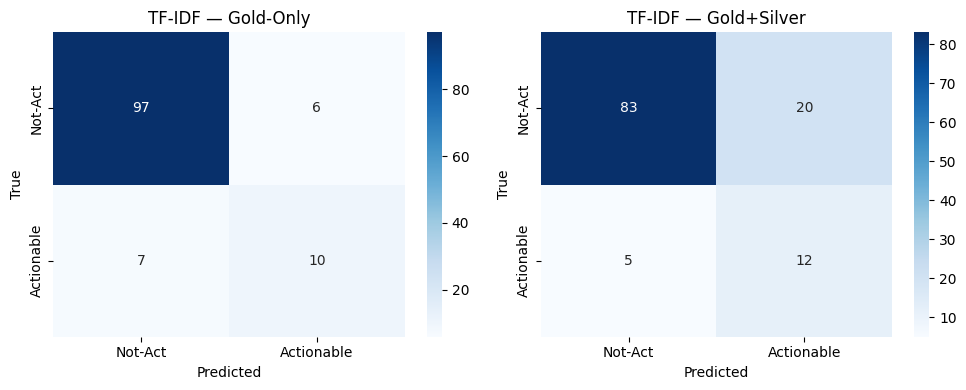


False Negatives — Gold-Only (missed actionable):
  • Pool schedule very limited at Balcones. Bulk item too infrequent. Hassle and poor availability of clinics in north Austin. Need more public fields. Wh
  • People routinely speed 10-20 miles over the 40 MPH speed limit on Davis Lane between Brodie and Mopac, which is super close to my neighborhood and whe
  • Rigs should not be allowed on 35. They should be forced to divert to I30. TX Dot needs to review and rewrite codes/laws if that's needed. Toll roads s
  • I wish the construction noise ordice violations were enforced more strictly. I live near the convention center and have been woken up by construction 
  • Need to enforce turning lanes in front of city hall
  • I have lived in Austin for over 40yrs and can say that the city does not maintain roads well, traffic is miserable and continues to get worse instead 
  • The highway traffic is terrible and negatively affects city street traffic (and pedestrian/cyclist safety) in the n

In [ ]:
# TF-IDF — Top Features & Confusion Matrices

# --- Top features (gold-only model) ---
feature_names = tfidf_gold.named_steps['tfidf'].get_feature_names_out()
coefs = tfidf_gold.named_steps['clf'].coef_[0]

top_k = 20
top_actionable_idx = np.argsort(coefs)[-top_k:][::-1]
top_not_actionable_idx = np.argsort(coefs)[:top_k]

print(f"Top {top_k} features for ACTIONABLE (gold-only model):")
for idx in top_actionable_idx:
    print(f"  {coefs[idx]:+.3f}  {feature_names[idx]}")

print(f"\nTop {top_k} features for NOT-ACTIONABLE (gold-only model):")
for idx in top_not_actionable_idx:
    print(f"  {coefs[idx]:+.3f}  {feature_names[idx]}")

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, preds, title in [
    (axes[0], tfidf_gold_preds, "TF-IDF — Gold-Only"),
    (axes[1], tfidf_combined_preds, "TF-IDF — Gold+Silver"),
]:
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not-Act', 'Actionable'],
                yticklabels=['Not-Act', 'Actionable'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# --- Error comparison ---
print("\nFalse Negatives — Gold-Only (missed actionable):")
for text, true, pred in zip(test_texts, test_labels, tfidf_gold_preds):
    if true == 1 and pred == 0:
        print(f"  • {text[:150]}")

print("\nFalse Negatives — Gold+Silver (missed actionable):")
for text, true, pred in zip(test_texts, test_labels, tfidf_combined_preds):
    if true == 1 and pred == 0:
        print(f"  • {text[:150]}")

---
# DistilRoBERTa Hyperparameter Sweep (Gold+Silver)
We first run a **tuning sweep** on DistilRoBERTa Gold+Silver to find the best
loss/regularization combination. The configurations test the key hypothesis that
Focal Loss + class weights may be double-correcting (causing excess false positives).

After the sweep, the **best config** is used for the final DistilRoBERTa training
(both Gold-Only and Gold+Silver), and carried through to the head-to-head comparison.

Configs tested:
| # | Loss | Class Weights | gamma | LR |
|---|------|--------------|-------|-----|
| A | Focal | Balanced | 2.0 | 2e-5 | (current default)
| B | Focal | None | 1.0 | 2e-5 | (reduce gamma, drop CW)
| C | Focal | None | 2.0 | 2e-5 | (drop CW only)
| D | CE | Balanced | n/a | 2e-5 | (standard CE + CW)
| E | CE | Balanced | n/a | 1e-5 | (lower LR)
| F | Focal | None | 1.0 | 1e-5 | (conservative)

In [ ]:
# Prepare Datasets for Transformers (Gold & Combined)

import torch
import datasets
from datasets import Dataset
from transformers import AutoTokenizer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MAX_LENGTH = 256

# We'll create tokenized datasets per model since tokenizers differ
def make_tokenize_fn(tok):
    def tokenize_fn(examples):
        return tok(
            examples['text'],
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
        )
    return tokenize_fn

# --- Raw datasets (pre-tokenization) ---
test_ds = Dataset.from_dict({'text': test_texts, 'label': test_labels})
test_ds = test_ds.cast_column('label', datasets.ClassLabel(names=['not_actionable', 'actionable']))

gold_train_ds = Dataset.from_dict({'text': gold_train_texts, 'label': gold_train_labels})
gold_train_ds = gold_train_ds.cast_column('label', datasets.ClassLabel(names=['not_actionable', 'actionable']))
gold_split = gold_train_ds.train_test_split(test_size=0.15, seed=42, stratify_by_column='label')

combined_train_ds = Dataset.from_dict({'text': combined_train_texts, 'label': combined_train_labels})
combined_train_ds = combined_train_ds.cast_column('label', datasets.ClassLabel(names=['not_actionable', 'actionable']))
combined_split = combined_train_ds.train_test_split(test_size=0.08, seed=42, stratify_by_column='label')

print(f'\nGold train/val:     {len(gold_split["train"])} / {len(gold_split["test"])}')
print(f'Combined train/val: {len(combined_split["train"])} / {len(combined_split["test"])}')
print(f'Test:               {len(test_ds)}')

def tokenize_splits(model_name):
    """Tokenize all splits for a given model. Returns (tokenizer, gold_train_tok, gold_val_tok, combined_train_tok, combined_val_tok, test_tok)."""
    tok = AutoTokenizer.from_pretrained(model_name)
    fn = make_tokenize_fn(tok)
    return (
        tok,
        gold_split['train'].map(fn, batched=True),
        gold_split['test'].map(fn, batched=True),
        combined_split['train'].map(fn, batched=True),
        combined_split['test'].map(fn, batched=True),
        test_ds.map(fn, batched=True),
    )


Device: cuda


Casting the dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2280 [00:00<?, ? examples/s]


Gold train/val:     408 / 72
Combined train/val: 2097 / 183
Test:               120


In [ ]:
# Training Infrastructure — Focal Loss, CE, Metrics, Args

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoModelForSequenceClassification,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# --- Focal Loss ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# --- Flexible Trainer: supports Focal or standard CE ---
class FlexTrainer(Trainer):
    def __init__(self, loss_type='focal', class_weights=None, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self._loss_type = loss_type
        if loss_type == 'focal':
            self._loss_fn = FocalLoss(alpha=class_weights, gamma=gamma)
        else:
            # Standard cross-entropy with optional class weights
            self._class_weights = class_weights
            self._loss_fn = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        if self._loss_type == 'focal':
            loss = self._loss_fn(outputs.logits, labels)
        else:
            loss = F.cross_entropy(outputs.logits, labels, weight=self._class_weights)
        return (loss, outputs) if return_outputs else loss

# Legacy alias so old references still work
class FocalTrainer(FlexTrainer):
    def __init__(self, class_weights=None, gamma=2.0, **kwargs):
        super().__init__(loss_type='focal', class_weights=class_weights, gamma=gamma, **kwargs)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)
    return {
        'f1': f1_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds),
        'roc_auc': roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.0,
    }

def get_training_args(output_dir, learning_rate=2e-5):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=10,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=32,
        gradient_accumulation_steps=2,
        learning_rate=learning_rate,
        weight_decay=0.1,
        warmup_ratio=0.1,
        lr_scheduler_type='cosine',
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        greater_is_better=True,
        save_total_limit=2,
        logging_steps=10,
        fp16=torch.cuda.is_available(),
        report_to='none',
        seed=42,
    )

def make_class_weights(labels):
    n_pos = sum(labels)
    n_neg = len(labels) - n_pos
    w0 = len(labels) / (2 * n_neg)
    w1 = len(labels) / (2 * n_pos)
    cw = torch.tensor([w0, w1], dtype=torch.float32).to(device)
    print(f'  Class weights: Not-Act={w0:.3f}, Act={w1:.3f}')
    return cw

def load_model_with_dropout(model_name, hidden_dropout=0.2, classifier_dropout=0.3):
    config = AutoConfig.from_pretrained(model_name, num_labels=2)
    if hasattr(config, 'hidden_dropout_prob'):
        config.hidden_dropout_prob = hidden_dropout
    if hasattr(config, 'attention_probs_dropout_prob'):
        config.attention_probs_dropout_prob = hidden_dropout
    if hasattr(config, 'classifier_dropout'):
        config.classifier_dropout = classifier_dropout
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config
    )
    return model

print('Training infrastructure ready.')
print('Key anti-overfitting measures:')
print('  - Early stopping (patience=3)')
print('  - Higher weight decay (0.1)')
print('  - Increased dropout (hidden=0.2, classifier=0.3)')
print('  - Fewer max epochs (10)')
print('  - FlexTrainer supports both Focal Loss and CrossEntropy')

Training infrastructure ready.
Key anti-overfitting measures:
  - Early stopping (patience=3)
  - Higher weight decay (0.1)
  - Increased dropout (hidden=0.2, classifier=0.3)
  - Fewer max epochs (10)
  - FlexTrainer supports both Focal Loss and CrossEntropy


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.562400,0.885472,0.000000,0.000000,0.000000,0.817653
2,0.131200,0.521962,0.727273,0.727273,0.727273,0.971459
4,0.011500,0.836740,0.700000,0.777778,0.636364,0.968023
6,0.321800,0.803875,0.761905,0.800000,0.727273,0.964059
8,0.047700,0.676508,0.761905,0.800000,0.727273,0.966173


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Val:  F1=0.762  P=0.800  R=0.727  AUC=0.967
  Test: F1=0.750  P=0.652  R=0.882  TP=15 FP=8 FN=2

--- F: Focal g=1, no CW, LR=1e-5 ---
  Class weights: None (disabled)


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.106600,0.104881,0.000000,0.000000,0.000000,0.881078
2,0.031300,0.058915,0.782609,0.750000,0.818182,0.971459
4,0.002700,0.079921,0.727273,0.727273,0.727273,0.967759
6,0.047000,0.081803,0.727273,0.727273,0.727273,0.966438


  Val:  F1=0.783  P=0.750  R=0.818  AUC=0.971
  Test: F1=0.703  P=0.650  R=0.765  TP=13 FP=7 FN=4

  SWEEP SUMMARY
                      Config  Val F1  Val P  Val R  Test F1  Test P  Test R  Test TP  Test FP  Test FN
A: Focal g=2 + CW (baseline)   0.857  0.900  0.818    0.750   0.652   0.882       15        8        2
         B: Focal g=1, no CW   0.783  0.750  0.818    0.714   0.600   0.882       15       10        2
         C: Focal g=2, no CW   0.818  0.818  0.818    0.718   0.636   0.824       14        8        3
                  D: CE + CW   0.783  0.750  0.818    0.750   0.652   0.882       15        8        2
         E: CE + CW, LR=1e-5   0.762  0.800  0.727    0.750   0.652   0.882       15        8        2
F: Focal g=1, no CW, LR=1e-5   0.783  0.750  0.818    0.703   0.650   0.765       13        7        4

** Best config (by val F1): A: Focal g=2 + CW (baseline)
   loss_type=focal, use_cw=True, gamma=2.0, lr=2e-05


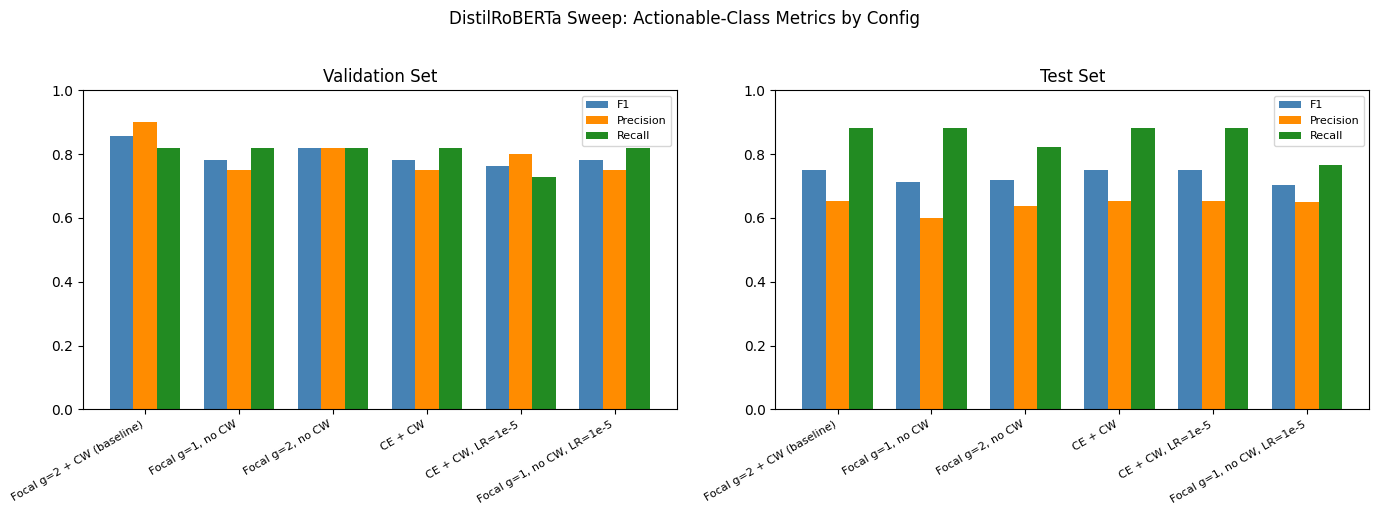

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  Training final DistilRoBERTa with best config: A: Focal g=2 + CW (baseline)

  DistilRoBERTa — GOLD-ONLY (best config)
  Class weights: Not-Act=0.580, Act=3.643


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.277000,0.240099,0.243902,0.138889,1.000000,0.785484
2,0.174000,0.157486,0.418605,0.272727,0.900000,0.888710
4,0.056100,0.124366,0.600000,0.450000,0.900000,0.901613
6,0.050100,0.152282,0.750000,0.642857,0.900000,0.901613
8,0.056600,0.180558,0.782609,0.692308,0.900000,0.904839
9,0.026700,0.182091,0.782609,0.692308,0.900000,0.904839


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  DistilRoBERTa — GOLD+SILVER (best config)
  Class weights: Not-Act=0.531, Act=8.594


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.293000,0.173185,0.169231,0.092437,1.000000,0.932875
2,0.179600,0.213678,0.720000,0.642857,0.818182,0.969345
4,0.003300,0.582155,0.631579,0.750000,0.545455,0.960888



** Final DistilRoBERTa models trained with best sweep config: A: Focal g=2 + CW (baseline)


In [ ]:
# DistilRoBERTa — Hyperparameter Sweep (Gold+Silver), then train best config

import gc

DISTIL_MODEL = 'distilroberta-base'

distil_tok, distil_gold_train_tok, distil_gold_val_tok, \
    distil_comb_train_tok, distil_comb_val_tok, distil_test_tok = tokenize_splits(DISTIL_MODEL)

# -- Sweep configs --
SWEEP_CONFIGS = {
    'A: Focal g=2 + CW (baseline)': dict(loss_type='focal', use_cw=True,  gamma=2.0, lr=2e-5),
    'B: Focal g=1, no CW':          dict(loss_type='focal', use_cw=False, gamma=1.0, lr=2e-5),
    'C: Focal g=2, no CW':          dict(loss_type='focal', use_cw=False, gamma=2.0, lr=2e-5),
    'D: CE + CW':                    dict(loss_type='ce',    use_cw=True,  gamma=None, lr=2e-5),
    'E: CE + CW, LR=1e-5':          dict(loss_type='ce',    use_cw=True,  gamma=None, lr=1e-5),
    'F: Focal g=1, no CW, LR=1e-5': dict(loss_type='focal', use_cw=False, gamma=1.0, lr=1e-5),
}

print('=' * 70)
print('  DistilRoBERTa HYPERPARAMETER SWEEP on Gold+Silver')
print('  Evaluated on held-out validation set')
print('=' * 70)

sweep_results = {}

for cfg_name, cfg in SWEEP_CONFIGS.items():
    print(f'\n--- {cfg_name} ---')

    cw = make_class_weights(combined_split['train']['label']) if cfg['use_cw'] else None
    if not cfg['use_cw']:
        print('  Class weights: None (disabled)')

    model = load_model_with_dropout(DISTIL_MODEL)

    trainer = FlexTrainer(
        loss_type=cfg['loss_type'],
        class_weights=cw,
        gamma=cfg.get('gamma', 2.0),
        model=model,
        args=get_training_args(f'./sweep_{cfg_name[:1]}', learning_rate=cfg['lr']),
        train_dataset=distil_comb_train_tok,
        eval_dataset=distil_comb_val_tok,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()

    # Evaluate on val AND test
    val_out = trainer.predict(distil_comb_val_tok)
    val_probs = torch.softmax(torch.tensor(val_out.predictions), dim=-1).numpy()[:, 1]
    val_preds = np.argmax(val_out.predictions, axis=-1)
    val_labels_arr = np.array(combined_split['test']['label'])

    test_out = trainer.predict(distil_test_tok)
    test_probs = torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy()[:, 1]
    test_preds = np.argmax(test_out.predictions, axis=-1)

    val_metrics = {
        'F1':  f1_score(val_labels_arr, val_preds),
        'P':   precision_score(val_labels_arr, val_preds, zero_division=0),
        'R':   recall_score(val_labels_arr, val_preds),
        'AUC': roc_auc_score(val_labels_arr, val_probs) if len(set(val_labels_arr)) > 1 else 0.0,
    }
    test_metrics = {
        'F1':  f1_score(test_labels, test_preds),
        'P':   precision_score(test_labels, test_preds, zero_division=0),
        'R':   recall_score(test_labels, test_preds),
        'AUC': roc_auc_score(test_labels, test_probs) if len(set(test_labels)) > 1 else 0.0,
        'TP':  sum(1 for t, p in zip(test_labels, test_preds) if t == 1 and p == 1),
        'FP':  sum(1 for t, p in zip(test_labels, test_preds) if t == 0 and p == 1),
        'FN':  sum(1 for t, p in zip(test_labels, test_preds) if t == 1 and p == 0),
    }
    sweep_results[cfg_name] = {'val': val_metrics, 'test': test_metrics, 'config': cfg}

    print(f'  Val:  F1={val_metrics["F1"]:.3f}  P={val_metrics["P"]:.3f}  R={val_metrics["R"]:.3f}  AUC={val_metrics["AUC"]:.3f}')
    print(f'  Test: F1={test_metrics["F1"]:.3f}  P={test_metrics["P"]:.3f}  R={test_metrics["R"]:.3f}  '
          f'TP={test_metrics["TP"]} FP={test_metrics["FP"]} FN={test_metrics["FN"]}')

    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# -- Sweep summary table --
print('\n' + '=' * 70)
print('  SWEEP SUMMARY')
print('=' * 70)
sweep_df = pd.DataFrame([
    {'Config': name, 'Val F1': r['val']['F1'], 'Val P': r['val']['P'], 'Val R': r['val']['R'],
     'Test F1': r['test']['F1'], 'Test P': r['test']['P'], 'Test R': r['test']['R'],
     'Test TP': r['test']['TP'], 'Test FP': r['test']['FP'], 'Test FN': r['test']['FN']}
    for name, r in sweep_results.items()
])
print(sweep_df.round(3).to_string(index=False))

# -- Select best config by VAL F1 --
best_cfg_name = max(sweep_results, key=lambda k: sweep_results[k]['val']['F1'])
best_cfg = sweep_results[best_cfg_name]['config']
print(f'\n** Best config (by val F1): {best_cfg_name}')
print(f'   loss_type={best_cfg["loss_type"]}, use_cw={best_cfg["use_cw"]}, '
      f'gamma={best_cfg.get("gamma")}, lr={best_cfg["lr"]}')

# -- Sweep visualization --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs = list(sweep_results.keys())
short_names = [c.split(': ')[1] if ': ' in c else c for c in configs]
x = np.arange(len(configs))
w = 0.25

val_f1s = [sweep_results[c]['val']['F1'] for c in configs]
val_ps  = [sweep_results[c]['val']['P'] for c in configs]
val_rs  = [sweep_results[c]['val']['R'] for c in configs]
axes[0].bar(x - w, val_f1s, w, label='F1', color='steelblue')
axes[0].bar(x,     val_ps,  w, label='Precision', color='darkorange')
axes[0].bar(x + w, val_rs,  w, label='Recall', color='forestgreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_title('Validation Set')
axes[0].legend(fontsize=8)

test_f1s = [sweep_results[c]['test']['F1'] for c in configs]
test_ps  = [sweep_results[c]['test']['P'] for c in configs]
test_rs  = [sweep_results[c]['test']['R'] for c in configs]
axes[1].bar(x - w, test_f1s, w, label='F1', color='steelblue')
axes[1].bar(x,     test_ps,  w, label='Precision', color='darkorange')
axes[1].bar(x + w, test_rs,  w, label='Recall', color='forestgreen')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title('Test Set')
axes[1].legend(fontsize=8)

plt.suptitle('DistilRoBERTa Sweep: Actionable-Class Metrics by Config', y=1.02)
plt.tight_layout()
plt.show()

# Train best config on Gold-Only AND Gold+Silver

print('\n' + '=' * 70)
print(f'  Training final DistilRoBERTa with best config: {best_cfg_name}')
print('=' * 70)

# --- Gold-Only ---
print('\n' + '=' * 60)
print('  DistilRoBERTa — GOLD-ONLY (best config)')
print('=' * 60)

distil_gold_cw = make_class_weights(gold_split['train']['label']) if best_cfg['use_cw'] else None
if not best_cfg['use_cw']:
    print('  Class weights: None (disabled)')
distil_gold_model = load_model_with_dropout(DISTIL_MODEL)

trainer_distil_gold = FlexTrainer(
    loss_type=best_cfg['loss_type'],
    class_weights=distil_gold_cw,
    gamma=best_cfg.get('gamma', 2.0),
    model=distil_gold_model,
    args=get_training_args('./distilroberta_gold_best', learning_rate=best_cfg['lr']),
    train_dataset=distil_gold_train_tok,
    eval_dataset=distil_gold_val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_distil_gold.train()

# --- Gold+Silver ---
print('\n' + '=' * 60)
print('  DistilRoBERTa — GOLD+SILVER (best config)')
print('=' * 60)

distil_comb_cw = make_class_weights(combined_split['train']['label']) if best_cfg['use_cw'] else None
if not best_cfg['use_cw']:
    print('  Class weights: None (disabled)')
distil_comb_model = load_model_with_dropout(DISTIL_MODEL)

trainer_distil_combined = FlexTrainer(
    loss_type=best_cfg['loss_type'],
    class_weights=distil_comb_cw,
    gamma=best_cfg.get('gamma', 2.0),
    model=distil_comb_model,
    args=get_training_args('./distilroberta_combined_best', learning_rate=best_cfg['lr']),
    train_dataset=distil_comb_train_tok,
    eval_dataset=distil_comb_val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_distil_combined.train()

print(f'\n** Final DistilRoBERTa models trained with best sweep config: {best_cfg_name}')

In [ ]:
# Evaluate DistilRoBERTa — Actionable-Class Metrics + Threshold Tuning

def get_probs_and_preds(trainer, tok_dataset, labels):
    """Return (probs, preds, actionable_metrics_dict)."""
    output = trainer.predict(tok_dataset)
    logits = output.predictions
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds  = np.argmax(logits, axis=-1)
    return probs, preds, {
        'F1':        f1_score(labels, preds),
        'Precision': precision_score(labels, preds, zero_division=0),
        'Recall':    recall_score(labels, preds),
        'ROC-AUC':   roc_auc_score(labels, probs) if len(set(labels)) > 1 else float('nan'),
    }

def evaluate_transformer(trainer, train_tok, val_tok, test_tok,
                         train_labels, val_labels, test_labels, model_name):
    """
    Evaluate Actionable-class metrics on train/val/test.
    Two threshold strategies tuned on val, applied to test.
    """
    train_probs, train_preds, train_m = get_probs_and_preds(trainer, train_tok, train_labels)
    val_probs,   val_preds,   val_m   = get_probs_and_preds(trainer, val_tok,   val_labels)
    test_probs,  test_preds,  test_m  = get_probs_and_preds(trainer, test_tok,  test_labels)

    print(f"\n{'=' * 60}")
    print(f'  {model_name} — Actionable Metrics (threshold=0.5)')
    print(f"{'=' * 60}")
    split_table = pd.DataFrame([train_m, val_m, test_m], index=['Train', 'Validation', 'Test'])
    print(split_table.round(3).to_string())

    f1_gap_val  = train_m['F1'] - val_m['F1']
    f1_gap_test = train_m['F1'] - test_m['F1']
    if f1_gap_val > 0.10 or f1_gap_test > 0.10:
        print(f'  ⚠  Possible overfitting — F1 gap: '
              f'train→val {f1_gap_val:+.3f}, train→test {f1_gap_test:+.3f}')
    else:
        print(f'  ✓  Train–test F1 gap is modest '
              f'(train→val {f1_gap_val:+.3f}, train→test {f1_gap_test:+.3f})')

    # Error counts on test set
    n_tp = sum(1 for t, p in zip(test_labels, test_preds) if t == 1 and p == 1)
    n_fp = sum(1 for t, p in zip(test_labels, test_preds) if t == 0 and p == 1)
    n_fn = sum(1 for t, p in zip(test_labels, test_preds) if t == 1 and p == 0)
    print(f'  Test: TP={n_tp}  FP={n_fp}  FN={n_fn}  (of {sum(test_labels)} true actionable)')

    # --- Strategy 1: Best Actionable F1 ---
    best_t, best_val_f1 = find_best_threshold(val_probs, val_labels)
    preds_f1_tuned = (test_probs >= best_t).astype(int)
    f1_t  = f1_score(test_labels, preds_f1_tuned)
    p_t   = precision_score(test_labels, preds_f1_tuned, zero_division=0)
    r_t   = recall_score(test_labels, preds_f1_tuned)
    tp_t  = sum(1 for t, p in zip(test_labels, preds_f1_tuned) if t == 1 and p == 1)
    fp_t  = sum(1 for t, p in zip(test_labels, preds_f1_tuned) if t == 0 and p == 1)
    fn_t  = sum(1 for t, p in zip(test_labels, preds_f1_tuned) if t == 1 and p == 0)
    print(f'\n  [Best-F1] threshold={best_t:.2f} (val F1={best_val_f1:.3f})')
    print(f'    Test: F1={f1_t:.3f}  P={p_t:.3f}  R={r_t:.3f}  TP={tp_t} FP={fp_t} FN={fn_t}')

    # --- Strategy 2: Max recall with precision >= 50% ---
    recall_t = find_recall_floor_threshold(val_probs, val_labels, min_precision=0.50)
    preds_recall = (test_probs >= recall_t).astype(int)
    f1_r  = f1_score(test_labels, preds_recall)
    p_r   = precision_score(test_labels, preds_recall, zero_division=0)
    r_r   = recall_score(test_labels, preds_recall)
    tp_r  = sum(1 for t, p in zip(test_labels, preds_recall) if t == 1 and p == 1)
    fp_r  = sum(1 for t, p in zip(test_labels, preds_recall) if t == 0 and p == 1)
    fn_r  = sum(1 for t, p in zip(test_labels, preds_recall) if t == 1 and p == 0)
    print(f'\n  [Max-Recall, P>=50%] threshold={recall_t:.2f}')
    print(f'    Test: F1={f1_r:.3f}  P={p_r:.3f}  R={r_r:.3f}  TP={tp_r} FP={fp_r} FN={fn_r}')

    return test_probs, test_preds, preds_f1_tuned, best_t, preds_recall, recall_t

# --- Evaluate DistilRoBERTa ---
gold_train_labels_arr = np.array(gold_split['train']['label'])
gold_val_labels_arr   = np.array(gold_split['test']['label'])
combined_train_labels_arr = np.array(combined_split['train']['label'])
combined_val_labels_arr   = np.array(combined_split['test']['label'])

distil_gold_probs, distil_gold_preds, distil_gold_preds_tuned, distil_gold_thresh, \
    distil_gold_preds_recall, distil_gold_recall_thresh = \
    evaluate_transformer(trainer_distil_gold,
                         distil_gold_train_tok, distil_gold_val_tok, distil_test_tok,
                         gold_train_labels_arr, gold_val_labels_arr, test_labels,
                         'DistilRoBERTa — Gold-Only')

distil_comb_probs, distil_comb_preds, distil_comb_preds_tuned, distil_comb_thresh, \
    distil_comb_preds_recall, distil_comb_recall_thresh = \
    evaluate_transformer(trainer_distil_combined,
                         distil_comb_train_tok, distil_comb_val_tok, distil_test_tok,
                         combined_train_labels_arr, combined_val_labels_arr, test_labels,
                         'DistilRoBERTa — Gold+Silver')



  DistilRoBERTa — Gold-Only — Actionable Metrics (threshold=0.5)
               F1  Precision  Recall  ROC-AUC
Train       0.894      0.821   0.982    0.994
Validation  0.783      0.692   0.900    0.903
Test        0.714      0.600   0.882    0.939
  ⚠  Possible overfitting — F1 gap: train→val +0.112, train→test +0.180
  Test: TP=15  FP=10  FN=2  (of 17.0 true actionable)

  [Best-F1] threshold=0.43 (val F1=0.783)
    Test: F1=0.727  P=0.593  R=0.941  TP=16 FP=11 FN=1

  [Max-Recall, P>=50%] threshold=0.19
    Test: F1=0.571  P=0.410  R=0.941  TP=16 FP=23 FN=1



  DistilRoBERTa — Gold+Silver — Actionable Metrics (threshold=0.5)
               F1  Precision  Recall  ROC-AUC
Train       0.764      0.758   0.770    0.981
Validation  0.857      0.900   0.818    0.978
Test        0.757      0.700   0.824    0.926
  ✓  Train–test F1 gap is modest (train→val -0.093, train→test +0.007)
  Test: TP=14  FP=6  FN=3  (of 17.0 true actionable)

  [Best-F1] threshold=0.42 (val F1=0.857)
    Test: F1=0.718  P=0.636  R=0.824  TP=14 FP=8 FN=3

  [Max-Recall, P>=50%] threshold=0.16
    Test: F1=0.500  P=0.340  R=0.941  TP=16 FP=31 FN=1


---
# RoBERTa-base Fine-tuning
Same training infrastructure as DistilRoBERTa, using the **same best config**
from the sweep (loss type, class weights, gamma, learning rate).
This ensures a fair apples-to-apples comparison between the two transformer architectures.

In [ ]:
# Fine-tune RoBERTa-base — Gold-Only & Gold+Silver (using best config from sweep)

import gc

ROBERTA_MODEL = 'roberta-base'

roberta_tok, roberta_gold_train_tok, roberta_gold_val_tok, \
    roberta_comb_train_tok, roberta_comb_val_tok, roberta_test_tok = tokenize_splits(ROBERTA_MODEL)

# --- Gold-Only ---
print('=' * 60)
print(f'  RoBERTa-base — GOLD-ONLY (config: {best_cfg_name})')
print('=' * 60)

roberta_gold_cw = make_class_weights(gold_split['train']['label']) if best_cfg['use_cw'] else None
if not best_cfg['use_cw']:
    print('  Class weights: None (disabled)')
roberta_gold_model = load_model_with_dropout(ROBERTA_MODEL)

trainer_roberta_gold = FlexTrainer(
    loss_type=best_cfg['loss_type'],
    class_weights=roberta_gold_cw,
    gamma=best_cfg.get('gamma', 2.0),
    model=roberta_gold_model,
    args=get_training_args('./roberta_gold_best', learning_rate=best_cfg['lr']),
    train_dataset=roberta_gold_train_tok,
    eval_dataset=roberta_gold_val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_roberta_gold.train()

# --- Gold+Silver ---
print('\n' + '=' * 60)
print(f'  RoBERTa-base — GOLD+SILVER (config: {best_cfg_name})')
print('=' * 60)

roberta_comb_cw = make_class_weights(combined_split['train']['label']) if best_cfg['use_cw'] else None
if not best_cfg['use_cw']:
    print('  Class weights: None (disabled)')
roberta_comb_model = load_model_with_dropout(ROBERTA_MODEL)

trainer_roberta_combined = FlexTrainer(
    loss_type=best_cfg['loss_type'],
    class_weights=roberta_comb_cw,
    gamma=best_cfg.get('gamma', 2.0),
    model=roberta_comb_model,
    args=get_training_args('./roberta_combined_best', learning_rate=best_cfg['lr']),
    train_dataset=roberta_comb_train_tok,
    eval_dataset=roberta_comb_val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer_roberta_combined.train()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.304200,0.263003,0.243902,0.138889,1.000000,0.832258
2,0.179600,0.122169,0.243902,0.138889,1.000000,0.930645
4,0.159200,0.140882,0.666667,0.529412,0.900000,0.916129
6,0.027500,0.187533,0.750000,0.642857,0.900000,0.919355
8,0.051700,0.190508,0.857143,0.818182,0.900000,0.915323
9,0.007100,0.194081,0.782609,0.692308,0.900000,0.914516


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



  RoBERTa-base — GOLD+SILVER (config: A: Focal g=2 + CW (baseline))
  Class weights: Not-Act=0.531, Act=8.594


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.286800,0.227522,0.145695,0.078571,1.000000,0.920190
2,0.191200,0.152018,0.571429,0.416667,0.909091,0.974630
4,0.051900,0.268329,0.782609,0.750000,0.818182,0.973309


In [ ]:
# Evaluate RoBERTa-base — Train / Val / Test

roberta_gold_probs, roberta_gold_preds, roberta_gold_preds_tuned, roberta_gold_thresh, \
    roberta_gold_preds_recall, roberta_gold_recall_thresh = \
    evaluate_transformer(trainer_roberta_gold,
                         roberta_gold_train_tok, roberta_gold_val_tok, roberta_test_tok,
                         gold_train_labels_arr, gold_val_labels_arr, test_labels,
                         'RoBERTa-base — Gold-Only')

roberta_comb_probs, roberta_comb_preds, roberta_comb_preds_tuned, roberta_comb_thresh, \
    roberta_comb_preds_recall, roberta_comb_recall_thresh = \
    evaluate_transformer(trainer_roberta_combined,
                         roberta_comb_train_tok, roberta_comb_val_tok, roberta_test_tok,
                         combined_train_labels_arr, combined_val_labels_arr, test_labels,
                         'RoBERTa-base — Gold+Silver')



  RoBERTa-base — Gold-Only — Actionable Metrics (threshold=0.5)
               F1  Precision  Recall  ROC-AUC
Train       0.932      0.887   0.982    0.996
Validation  0.857      0.818   0.900    0.921
Test        0.778      0.737   0.824    0.953
  ⚠  Possible overfitting — F1 gap: train→val +0.075, train→test +0.154
  Test: TP=14  FP=5  FN=3  (of 17.0 true actionable)

  [Best-F1] threshold=0.15 (val F1=0.857)
    Test: F1=0.714  P=0.600  R=0.882  TP=15 FP=10 FN=2

  [Max-Recall, P>=50%] threshold=0.15
    Test: F1=0.714  P=0.600  R=0.882  TP=15 FP=10 FN=2



  RoBERTa-base — Gold+Silver — Actionable Metrics (threshold=0.5)
               F1  Precision  Recall  ROC-AUC
Train       0.675      0.563   0.844    0.968
Validation  0.783      0.750   0.818    0.967
Test        0.652      0.517   0.882    0.922
  ✓  Train–test F1 gap is modest (train→val -0.107, train→test +0.023)
  Test: TP=15  FP=14  FN=2  (of 17.0 true actionable)

  [Best-F1] threshold=0.46 (val F1=0.783)
    Test: F1=0.638  P=0.500  R=0.882  TP=15 FP=15 FN=2

  [Max-Recall, P>=50%] threshold=0.24
    Test: F1=0.552  P=0.390  R=0.941  TP=16 FP=25 FN=1


---
# Stratified 5-Fold Cross-Validation (All Transformers)
The single train/test split above evaluates on only **17 Actionable examples** —
too few for stable metrics. This section runs stratified 5-fold CV on the full
gold set so every Actionable comment gets evaluated exactly once.



  DistilRoBERTa — Gold — 5-Fold CV


Casting the dataset:   0%|          | 0/480 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/422 [00:00<?, ? examples/s]

Map:   0%|          | 0/58 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Class weights: Not-Act=0.531, Act=8.571


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Roc Auc
0,0.432700,0.212422,0.137339,0.073733,1.000000,0.909157
2,0.273500,0.125713,0.666667,0.538462,0.875000,0.975775
4,0.122100,0.300984,0.666667,0.647059,0.687500,0.978440
6,0.058000,0.389087,0.666667,0.647059,0.687500,0.978682


  Fold 4: F1=0.696  P=0.552  R=0.941  AUC=0.975

  CROSS-VALIDATION SUMMARY

DistilRoBERTa — Gold:
  f1          : 0.691 +/- 0.055  (folds: 0.632, 0.619, 0.744, 0.718, 0.744)
  precision   : 0.583 +/- 0.051  (folds: 0.545, 0.500, 0.615, 0.636, 0.615)
  recall      : 0.854 +/- 0.076  (folds: 0.750, 0.812, 0.941, 0.824, 0.941)
  roc_auc     : 0.934 +/- 0.043  (folds: 0.913, 0.869, 0.986, 0.925, 0.976)

DistilRoBERTa — Gold+Silver:
  f1          : 0.762 +/- 0.094  (folds: 0.667, 0.649, 0.895, 0.833, 0.765)
  precision   : 0.716 +/- 0.092  (folds: 0.647, 0.571, 0.810, 0.789, 0.765)
  recall      : 0.817 +/- 0.111  (folds: 0.688, 0.750, 1.000, 0.882, 0.765)
  roc_auc     : 0.965 +/- 0.022  (folds: 0.945, 0.940, 0.997, 0.962, 0.981)

RoBERTa-base — Gold:
  f1          : 0.756 +/- 0.091  (folds: 0.667, 0.645, 0.872, 0.757, 0.842)
  precision   : 0.688 +/- 0.084  (folds: 0.538, 0.667, 0.773, 0.700, 0.762)
  recall      : 0.853 +/- 0.129  (folds: 0.875, 0.625, 1.000, 0.824, 0.941)
  roc_auc    

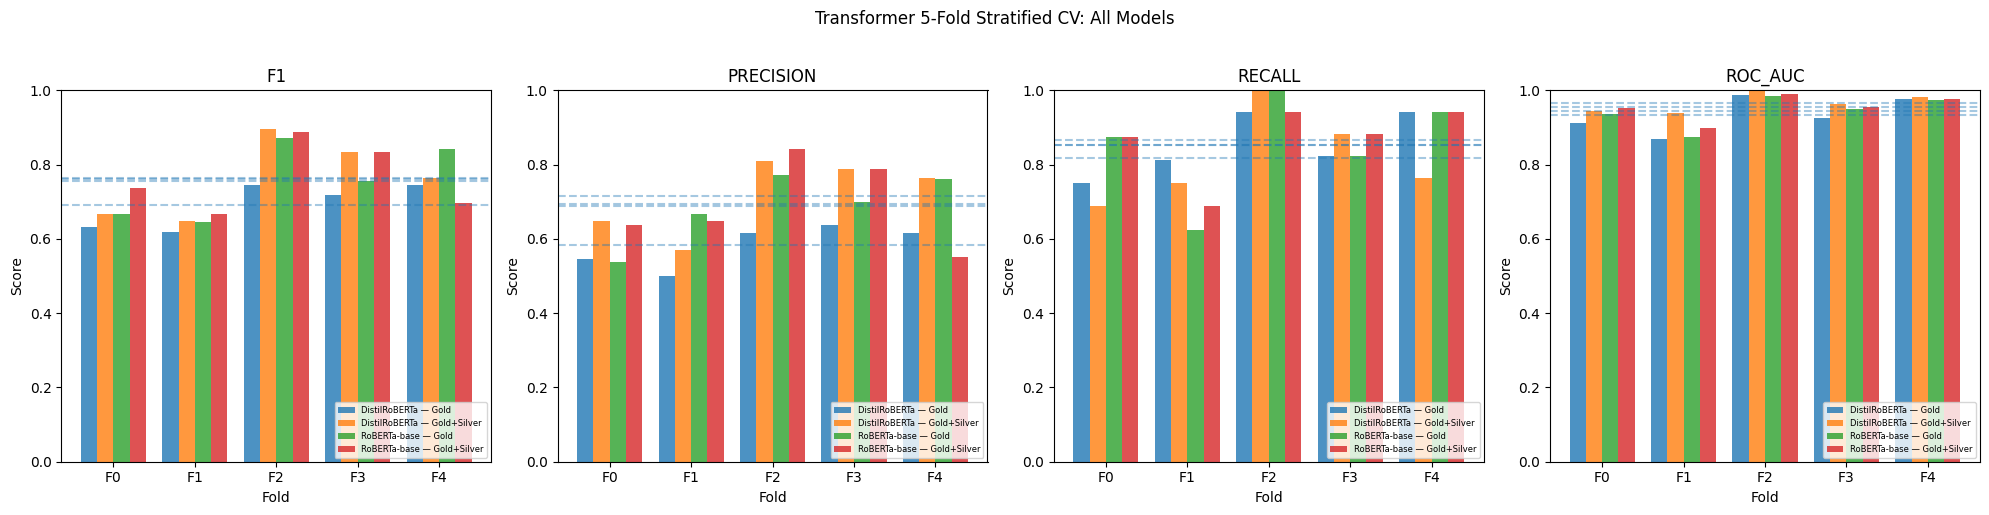

In [ ]:
# Stratified 5-Fold CV — DistilRoBERTa & RoBERTa-base (Gold & Gold+Silver)

from sklearn.model_selection import StratifiedKFold
import gc

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

gold_all_texts = gold_df['comment_text'].astype(str).tolist()
gold_all_labels = gold_df['binary_human_corrected'].tolist()
silver_texts_cv = silver_df['comment_text'].astype(str).tolist()
silver_labels_cv = silver_df['binary_sonnet'].tolist()

def run_cv_fold(model_name, train_texts, train_labels,
                test_texts_fold, test_labels_fold, fold_num, tag):
    """Train one transformer fold and return metrics dict."""
    tok = AutoTokenizer.from_pretrained(model_name)
    fn = make_tokenize_fn(tok)

    train_ds = Dataset.from_dict({'text': train_texts, 'label': train_labels})
    train_ds = train_ds.cast_column('label', datasets.ClassLabel(names=['not_actionable', 'actionable']))
    test_ds = Dataset.from_dict({'text': test_texts_fold, 'label': test_labels_fold})
    test_ds = test_ds.cast_column('label', datasets.ClassLabel(names=['not_actionable', 'actionable']))

    split = train_ds.train_test_split(test_size=0.12, seed=42, stratify_by_column='label')
    train_tok = split['train'].map(fn, batched=True)
    val_tok = split['test'].map(fn, batched=True)
    test_tok_fold = test_ds.map(fn, batched=True)

    cw = make_class_weights(train_labels) if best_cfg['use_cw'] else None
    if not best_cfg['use_cw']:
        print('    Class weights: None (disabled)')
    model = load_model_with_dropout(model_name)

    trainer = FlexTrainer(
        loss_type=best_cfg['loss_type'],
        class_weights=cw,
        gamma=best_cfg.get('gamma', 2.0),
        model=model,
        args=get_training_args(f'./cv_{tag}_fold{fold_num}', learning_rate=best_cfg['lr']),
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    trainer.train()

    output = trainer.predict(test_tok_fold)
    logits = output.predictions
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = np.argmax(logits, axis=-1)

    metrics = {
        'f1': f1_score(test_labels_fold, preds),
        'precision': precision_score(test_labels_fold, preds, zero_division=0),
        'recall': recall_score(test_labels_fold, preds),
        'roc_auc': roc_auc_score(test_labels_fold, probs) if len(set(test_labels_fold)) > 1 else 0.0,
    }
    print(f'  Fold {fold_num}: F1={metrics["f1"]:.3f}  P={metrics["precision"]:.3f}  '
          f'R={metrics["recall"]:.3f}  AUC={metrics["roc_auc"]:.3f}')

    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return metrics

all_cv_results = {}

for model_tag, model_name in [('DistilRoBERTa', 'distilroberta-base'), ('RoBERTa-base', 'roberta-base')]:
    for data_tag, use_silver in [('Gold', False), ('Gold+Silver', True)]:
        label = f'{model_tag} — {data_tag}'
        print('\n' + '=' * 60)
        print(f'  {label} — 5-Fold CV')
        print('=' * 60)

        fold_results = []
        for fold, (train_idx, test_idx) in enumerate(skf.split(gold_all_texts, gold_all_labels)):
            fold_train_texts = [gold_all_texts[i] for i in train_idx]
            fold_train_labels = [gold_all_labels[i] for i in train_idx]
            if use_silver:
                fold_train_texts += silver_texts_cv
                fold_train_labels += silver_labels_cv
            fold_test_texts = [gold_all_texts[i] for i in test_idx]
            fold_test_labels = [gold_all_labels[i] for i in test_idx]

            m = run_cv_fold(model_name, fold_train_texts, fold_train_labels,
                            fold_test_texts, fold_test_labels, fold, f'{model_tag}_{data_tag}')
            fold_results.append(m)

        all_cv_results[label] = fold_results

# --- Summary ---
print('\n' + '=' * 60)
print('  CROSS-VALIDATION SUMMARY')
print('=' * 60)

for tag, results in all_cv_results.items():
    print(f'\n{tag}:')
    for metric in ['f1', 'precision', 'recall', 'roc_auc']:
        vals = [r[metric] for r in results]
        print(f'  {metric:<12s}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}  '
              f'(folds: {", ".join(f"{v:.3f}" for v in vals)})')

# --- Visual comparison ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, ['f1', 'precision', 'recall', 'roc_auc']):
    x = np.arange(N_FOLDS)
    width = 0.2
    for i, (tag, results) in enumerate(all_cv_results.items()):
        vals = [r[metric] for r in results]
        ax.bar(x + i * width, vals, width, label=tag, alpha=0.8)
        ax.axhline(np.mean(vals), linestyle='--', alpha=0.4)

    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_title(metric.upper())
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels([f'F{i}' for i in range(N_FOLDS)])
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right', fontsize=6)

plt.suptitle('Transformer 5-Fold Stratified CV: All Models', y=1.02)
plt.tight_layout()
plt.show()


---
# Head-to-Head Comparison

Six models (3 architectures × 2 training sets), all evaluated on the **same held-out gold test set**.
Transformer models are reported at both the default threshold (0.5) and the validation-tuned threshold.


DistilRoBERTa & RoBERTa-base trained with sweep winner: A: Focal g=2 + CW (baseline)
  loss=focal, CW=True, gamma=2.0, lr=2e-05

  Actionable-Class Metrics — Held-out test (17.0 actionable / 120 total)
                 Model   Data    F1     P     R   AUC  TP  FP  FN
                TF-IDF   Gold 0.606 0.625 0.588 0.852  10   6   7
                TF-IDF Gold+S 0.490 0.375 0.706 0.838  12  20   5
        TF-IDF (tuned)   Gold 0.519 0.378 0.824 0.852  14  23   3
         DistilRoBERTa   Gold 0.714 0.600 0.882 0.939  15  10   2
         DistilRoBERTa Gold+S 0.757 0.700 0.824 0.926  14   6   3
    DistilRoBERTa (F1)   Gold 0.727 0.593 0.941 0.939  16  11   1
    DistilRoBERTa (F1) Gold+S 0.718 0.636 0.824 0.926  14   8   3
DistilRoBERTa (recall)   Gold 0.571 0.410 0.941 0.939  16  23   1
DistilRoBERTa (recall) Gold+S 0.500 0.340 0.941 0.926  16  31   1
          RoBERTa-base   Gold 0.778 0.737 0.824 0.953  14   5   3
          RoBERTa-base Gold+S 0.652 0.517 0.882 0.922  15  14   2
     R

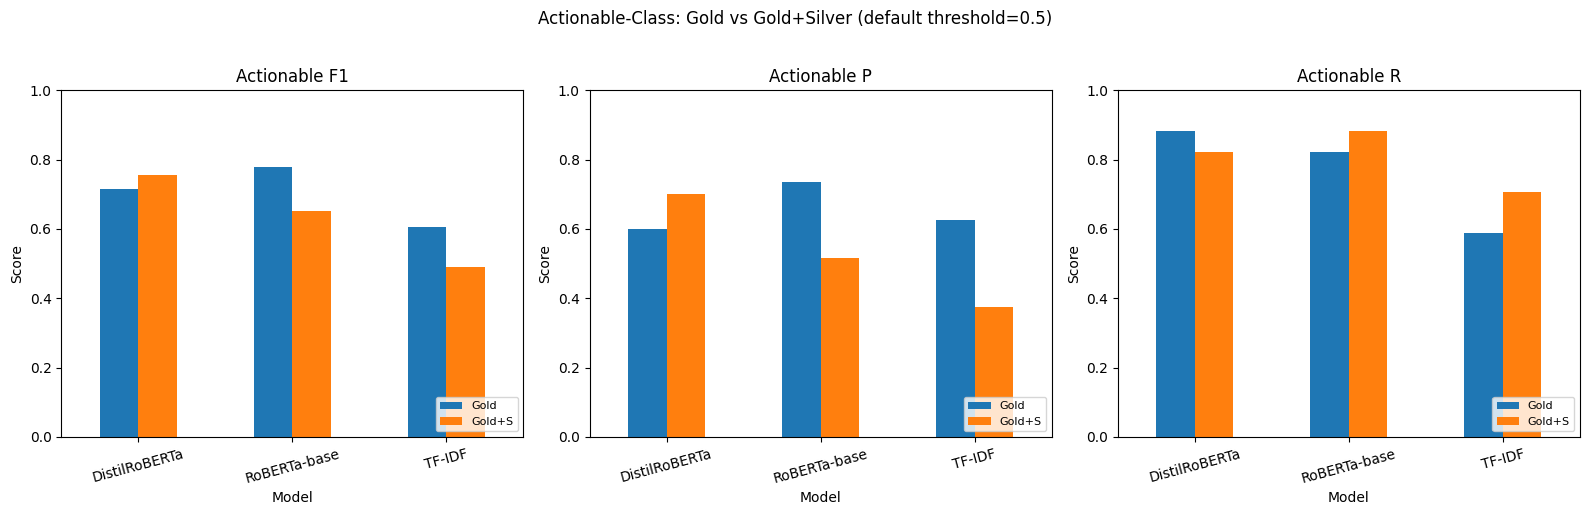


  Best model per strategy
  (F1): DistilRoBERTa (F1) / Gold — F1=0.727 P=0.593 R=0.941 (TP=16 FP=11 FN=1)
  (recall): RoBERTa-base (recall) / Gold — F1=0.714 P=0.600 R=0.882 (TP=15 FP=10 FN=2)


In [ ]:
# Head-to-Head — Actionable-Class Metrics

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print(f'DistilRoBERTa & RoBERTa-base trained with sweep winner: {best_cfg_name}')
print(f'  loss={best_cfg["loss_type"]}, CW={best_cfg["use_cw"]}, gamma={best_cfg.get("gamma")}, lr={best_cfg["lr"]}')
print()

results = []

def add_result(name, data_tag, true, preds, probs=None):
    n_tp = sum(1 for t, p in zip(true, preds) if t == 1 and p == 1)
    n_fp = sum(1 for t, p in zip(true, preds) if t == 0 and p == 1)
    n_fn = sum(1 for t, p in zip(true, preds) if t == 1 and p == 0)
    results.append({
        'Model': name,
        'Data': data_tag,
        'F1':   f1_score(true, preds),
        'P':    precision_score(true, preds, zero_division=0),
        'R':    recall_score(true, preds),
        'AUC':  roc_auc_score(true, probs) if probs is not None else float('nan'),
        'TP': n_tp, 'FP': n_fp, 'FN': n_fn,
    })

# TF-IDF
add_result('TF-IDF',          'Gold',   test_labels, tfidf_gold_preds,       tfidf_gold_probs)
add_result('TF-IDF',          'Gold+S', test_labels, tfidf_combined_preds,    tfidf_combined_probs)
add_result('TF-IDF (tuned)',   'Gold',   test_labels, tfidf_gold_preds_tuned, tfidf_gold_probs)

# DistilRoBERTa
add_result('DistilRoBERTa',          'Gold',   test_labels, distil_gold_preds,         distil_gold_probs)
add_result('DistilRoBERTa',          'Gold+S', test_labels, distil_comb_preds,         distil_comb_probs)
add_result('DistilRoBERTa (F1)',     'Gold',   test_labels, distil_gold_preds_tuned,   distil_gold_probs)
add_result('DistilRoBERTa (F1)',     'Gold+S', test_labels, distil_comb_preds_tuned,   distil_comb_probs)
add_result('DistilRoBERTa (recall)', 'Gold',   test_labels, distil_gold_preds_recall,  distil_gold_probs)
add_result('DistilRoBERTa (recall)', 'Gold+S', test_labels, distil_comb_preds_recall,  distil_comb_probs)

# RoBERTa-base
add_result('RoBERTa-base',          'Gold',   test_labels, roberta_gold_preds,         roberta_gold_probs)
add_result('RoBERTa-base',          'Gold+S', test_labels, roberta_comb_preds,         roberta_comb_probs)
add_result('RoBERTa-base (F1)',     'Gold',   test_labels, roberta_gold_preds_tuned,   roberta_gold_probs)
add_result('RoBERTa-base (F1)',     'Gold+S', test_labels, roberta_comb_preds_tuned,   roberta_comb_probs)
add_result('RoBERTa-base (recall)', 'Gold',   test_labels, roberta_gold_preds_recall,  roberta_gold_probs)
add_result('RoBERTa-base (recall)', 'Gold+S', test_labels, roberta_comb_preds_recall,  roberta_comb_probs)

comparison_df = pd.DataFrame(results)

print('=' * 90)
print(f'  Actionable-Class Metrics — Held-out test ({sum(test_labels)} actionable / {len(test_labels)} total)')
print('=' * 90)
print(comparison_df.round(3).to_string(index=False))

# --- Bar chart ---
chart_df = comparison_df[
    ~comparison_df['Model'].str.contains('tuned|F1|recall', regex=True)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['F1', 'P', 'R']):
    pivot = chart_df.pivot(index='Model', columns='Data', values=metric)
    pivot = pivot[['Gold', 'Gold+S']]
    pivot.plot(kind='bar', ax=ax, rot=15)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title(f'Actionable {metric}')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Actionable-Class: Gold vs Gold+Silver (default threshold=0.5)', y=1.02)
plt.tight_layout()
plt.show()

# --- Best configs ---
print('\n' + '=' * 90)
print('  Best model per strategy')
print('=' * 90)
for strategy in ['(F1)', '(recall)']:
    subset = comparison_df[comparison_df['Model'].str.contains(strategy, regex=False)]
    if len(subset) > 0:
        best = subset.loc[subset['F1'].idxmax()]
        print(f'  {strategy}: {best["Model"]} / {best["Data"]} — '
              f'F1={best["F1"]:.3f} P={best["P"]:.3f} R={best["R"]:.3f} '
              f'(TP={int(best["TP"])} FP={int(best["FP"])} FN={int(best["FN"])})')


In [ ]:
# Inference on Full Dataset — All Models for Spot-Checking

all_texts = all_comments_df['comment_clean'].astype(str).tolist()

# --- TF-IDF ---
all_comments_df['pred_tfidf_gold']   = tfidf_gold.predict(all_texts)
all_comments_df['prob_tfidf_gold']    = tfidf_gold.predict_proba(all_texts)[:, 1]
all_comments_df['pred_tfidf_silver']  = tfidf_combined.predict(all_texts)
all_comments_df['prob_tfidf_silver']  = tfidf_combined.predict_proba(all_texts)[:, 1]

# --- DistilRoBERTa ---
from transformers import pipeline as hf_pipeline

distil_gold_clf = hf_pipeline(
    'text-classification', model=trainer_distil_gold.model, tokenizer=distil_tok,
    device=0 if torch.cuda.is_available() else -1
)
distil_comb_clf = hf_pipeline(
    'text-classification', model=trainer_distil_combined.model, tokenizer=distil_tok,
    device=0 if torch.cuda.is_available() else -1
)

distil_gold_results = distil_gold_clf(all_texts, batch_size=64, truncation=True, max_length=MAX_LENGTH)
all_comments_df['prob_distil_gold'] = [
    r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in distil_gold_results
]
all_comments_df['pred_distil_gold'] = (all_comments_df['prob_distil_gold'] >= 0.5).astype(int)

distil_comb_results = distil_comb_clf(all_texts, batch_size=64, truncation=True, max_length=MAX_LENGTH)
all_comments_df['prob_distil_silver'] = [
    r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in distil_comb_results
]
all_comments_df['pred_distil_silver'] = (all_comments_df['prob_distil_silver'] >= 0.5).astype(int)

# --- RoBERTa-base ---
roberta_gold_clf = hf_pipeline(
    'text-classification', model=trainer_roberta_gold.model, tokenizer=roberta_tok,
    device=0 if torch.cuda.is_available() else -1
)
roberta_comb_clf = hf_pipeline(
    'text-classification', model=trainer_roberta_combined.model, tokenizer=roberta_tok,
    device=0 if torch.cuda.is_available() else -1
)

roberta_gold_results = roberta_gold_clf(all_texts, batch_size=64, truncation=True, max_length=MAX_LENGTH)
all_comments_df['prob_roberta_gold'] = [
    r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in roberta_gold_results
]
all_comments_df['pred_roberta_gold'] = (all_comments_df['prob_roberta_gold'] >= 0.5).astype(int)

roberta_comb_results = roberta_comb_clf(all_texts, batch_size=64, truncation=True, max_length=MAX_LENGTH)
all_comments_df['prob_roberta_silver'] = [
    r['score'] if r['label'] == 'LABEL_1' else 1 - r['score'] for r in roberta_comb_results
]
all_comments_df['pred_roberta_silver'] = (all_comments_df['prob_roberta_silver'] >= 0.5).astype(int)

# --- Summary ---
core_models = [
    ('TF-IDF Gold',           'pred_tfidf_gold'),
    ('TF-IDF Gold+Silver',    'pred_tfidf_silver'),
    ('DistilRoBERTa Gold',    'pred_distil_gold'),
    ('DistilRoBERTa Gold+Silver', 'pred_distil_silver'),
    ('RoBERTa-base Gold',     'pred_roberta_gold'),
    ('RoBERTa-base Gold+Silver', 'pred_roberta_silver'),
]

print(f'Predictions on {len(all_texts):,} comments:\n')
print(f'{"Model":<30s} {"Actionable":>10s} {"Not-Act":>10s} {"Rate":>8s}')
print('-' * 60)
for name, col in core_models:
    n_act = int(all_comments_df[col].sum())
    n_not = len(all_comments_df) - n_act
    rate  = all_comments_df[col].mean()
    print(f'{name:<30s} {n_act:>10d} {n_not:>10d} {rate:>8.1%}')

# --- Ensemble voting (6 models) ---
pred_cols = [col for _, col in core_models]
all_comments_df['vote_count'] = all_comments_df[pred_cols].sum(axis=1)
all_comments_df['all_agree_actionable'] = (all_comments_df['vote_count'] == len(pred_cols)).astype(int)

majority_threshold = len(pred_cols) // 2 + 1  # 4 of 6
n_unanimous = all_comments_df['all_agree_actionable'].sum()
n_majority  = (all_comments_df['vote_count'] >= majority_threshold).sum()
n_any       = (all_comments_df['vote_count'] >= 1).sum()

print(f'\nEnsemble agreement (6 models):')
print(f'  Unanimous (6/6):  {n_unanimous}')
print(f'  Majority  (>=4/6): {n_majority}')
print(f'  Any       (>=1/6): {n_any}')


Predictions on 13,542 comments:

Model                          Actionable    Not-Act     Rate
------------------------------------------------------------
TF-IDF Gold                           293      13249     2.2%
TF-IDF Gold+Silver                    671      12871     5.0%
DistilRoBERTa Gold                    639      12903     4.7%
DistilRoBERTa Gold+Silver             546      12996     4.0%
RoBERTa-base Gold                     466      13076     3.4%
RoBERTa-base Gold+Silver              835      12707     6.2%

Ensemble agreement (6 models):
  Unanimous (6/6):  141
  Majority  (>=4/6): 444
  Any       (>=1/6): 1253


In [ ]:
# Spot-Check: Unanimous Actionable

import textwrap

print("=" * 60)
print("  UNANIMOUS ACTIONABLE (all 6 models agree)")
print("=" * 60 + "\n")

unanimous = all_comments_df[all_comments_df["all_agree_actionable"] == 1]
for i, (_, row) in enumerate(unanimous.head(25).iterrows()):
    text = row["comment_clean"] if len(row["comment_clean"]) <= 300 else row["comment_clean"][:300] + "..."
    wrapped = textwrap.fill(text, width=90, initial_indent="  ", subsequent_indent="  ")
    print(f"[{i+1}] ({int(row['vote_count'])}/6)")
    print(wrapped)
    print()


  UNANIMOUS ACTIONABLE (all 6 models agree)

[1] (6/6)
  Construction crews do a horrible job repairing work. If their work was done on my
  personal home, I would not pay them for their efforts. So many pot-holes and many
  horrible patch jobs. They are also tearing up many streets and making improvements that
  are not only concerning but unsafe. For example,...

[2] (6/6)
  Traffic light timing is oftentimes entirely disconnected to the reality of traffic
  movement needs. Traffic flow on major streets and highways oftentimes seems to be a
  byproduct of poor planning and a fundamental lack of understanding of driver behavior.
  The main problem with traffic flow is bottlene...

[3] (6/6)
  Lack of enforcement of tree hangovers prevents light from street lights on of
  meadowheath and water mill cove 78729 lighting the street.

[4] (6/6)
  I am dissatisfied with the maintece of major city streets; because I reported the Poor
  Condition of the street pavement from Stassney St. on So

In [ ]:
# Spot-Check: Contentious (models disagree)

import textwrap

print("=" * 60)
print("  CONTENTIOUS — exactly 3/6 models say actionable")
print("=" * 60 + "\n")

contentious = all_comments_df[all_comments_df["vote_count"] == 3]
for i, (_, row) in enumerate(contentious.sample(min(20, len(contentious)), random_state=42).iterrows()):
    flagged_by = [name for name, col in core_models if row[col] == 1]
    text = row["comment_clean"] if len(row["comment_clean"]) <= 300 else row["comment_clean"][:300] + "..."
    wrapped = textwrap.fill(text, width=90, initial_indent="  ", subsequent_indent="  ")
    print(f"[{i+1}] Flagged by: {', '.join(flagged_by)}")
    print(wrapped)
    print()


  CONTENTIOUS — exactly 3/6 models say actionable

[1] Flagged by: DistilRoBERTa Gold, RoBERTa-base Gold, RoBERTa-base Gold+Silver
  Code compliance enforcement in my neighborhood lacks. Yard maintece, yard parking are
  ignored with lots of violations in the St. John neighborhood... but I guess it will
  remain low priority until it fully gentrifies and most of the historical residents are
  no longer here.

[2] Flagged by: TF-IDF Gold+Silver, RoBERTa-base Gold, RoBERTa-base Gold+Silver
  Greg Mazaros should be fired. I think that's his name. You know who I am speaking of
  Lady Bird Lake is a toxic waste area, dogs dying from no answers to the annual algae.
  Homeless causing our streets to be polluted.

[3] Flagged by: DistilRoBERTa Gold, DistilRoBERTa Gold+Silver, RoBERTa-base Gold+Silver
  For South Austin (Slaughter) has a lot of new development, but no hike and bike trails,
  only non-shaded sidewalks along busy roads.

[4] Flagged by: TF-IDF Gold+Silver, DistilRoBERTa Gold, RoB

In [ ]:
# Save Full Predictions

SAVE_DIR = "/content/drive/MyDrive/austin_survey_models"
output_path = f"{SAVE_DIR}/all_comments_all_model_predictions.csv"
all_comments_df.to_csv(output_path, index=False)
print(f"Saved to: {output_path}")
print(f"Columns: {[c for c in all_comments_df.columns if 'pred_' in c or 'vote' in c or 'agree' in c]}")

# --- Save DistilRoBERTa G+S flagged comments specifically ---
distil_gs_flagged = all_comments_df[all_comments_df['pred_distil_silver'] == 1].copy()
distil_gs_path = f"{SAVE_DIR}/distilroberta_gs_flagged_actionable.csv"
distil_gs_flagged.to_csv(distil_gs_path, index=False)
print(f"\nDistilRoBERTa G+S flagged {len(distil_gs_flagged)} comments as actionable")
print(f"Saved to: {distil_gs_path}")


Saved to: /content/drive/MyDrive/austin_survey_models/all_comments_all_model_predictions.csv
Columns: ['pred_tfidf_gold', 'pred_tfidf_silver', 'pred_distil_gold', 'pred_distil_silver', 'pred_roberta_gold', 'pred_roberta_silver', 'vote_count', 'all_agree_actionable']

DistilRoBERTa G+S flagged 546 comments as actionable
Saved to: /content/drive/MyDrive/austin_survey_models/distilroberta_gs_flagged_actionable.csv


# AI Citation Section

Cleaned up formatting of print statements, used to generate facy print tables to better present results to future readers, Sonnet 4.6, Anthropic

Reorganized messy code and remove unused code, Sonnet 4.6, Anthropic

Used to resolve dependancy version conflicts, Opus 4.6, Anthropic

Typeahead used in some cases, Google Colab - Gemini, Google